# Bootstrap Active Learning — Random Sampling vs Uncertainty Sampling

**Architecture** :
- **N_SIM simulations** de Random Sampling (seeds variables)
- **N_SIM simulations** d'Uncertainty Sampling (mêmes seeds que RS)

Chaque simulation = une trajectoire complète d'active learning avec son propre
split de données. Les N trajectoires sont tracées individuellement + moyenne + IC 90%.
Pas de LLM dans ce notebook.

## 1. Imports

In [19]:
import pandas as pd
import copy
import time
import numpy as np
import re
import os
import seaborn as sns
import matplotlib.pyplot as plt

from joblib import load
from preprocessor import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score, roc_curve
)
from sklearn.metrics.pairwise import euclidean_distances
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

from openai import OpenAI
from Preprocessor_LLM import *
from Preprocessor_LLM_RAG import *

print('✓ Imports OK')

✓ Imports OK


## 2. Configuration — tous les hyperparamètres ici

In [ ]:
# ── Données ──────────────────────────────────────────────────────────────────
DATA_PATH        = '/home/onyxia/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv'
OUTPUT_DIR       = '/home/onyxia/PROJET_STATAPP/Notebooks/sorties/'

# ── Split ────────────────────────────────────────────────────────────────────
TEST_SIZE        = 0.2    # fraction réservée au test (commune à toutes les sims)
SEED_SIZE        = 0.02    # observations initiales (seed AL)
BASE_SEED        = 42     # seed de base — sim i utilise BASE_SEED + i

# ── Boucle AL ────────────────────────────────────────────────────────────────
BATCH_SIZE       = 50     # observations ajoutées à chaque itération
LABEL_MAX        = 8000   # budget total de labels
WARMUP_ITERS     = 10      # itérations random avant d'activer l'uncertainty

# ── Uncertainty Sampling ─────────────────────────────────────────────────────
DIVERSITY_ALPHA  = 0.3   # poids incertitude vs diversité (0=div pure, 1=unc pure)

# ── Bootstrap ────────────────────────────────────────────────────────────────
N_SIM            = 4     # ← nombre de simulations pour RS ET US

# ── SMOTE ────────────────────────────────────────────────────────────────────
SMOTE_RATIO      = 0.25


# ── LLM (Mistral via OpenAI-compatible endpoint) ─────────────────────────────
N_LLM_SIMS        = 30
N_PRESELECT       = 1000
N_SELECT          = 50
N_RAG             = 30
SEUIL_AUC         = 0.02
METHODE           = 'DPO_with_RAG'
MISTRAL_API_KEY   = 'dJRikqTHAfXagIP0C8nFWb2AJf7JYvz0'
MISTRAL_BASE_URL  = 'https://api.mistral.ai/v1'
MISTRAL_MODEL     = 'mistral-small-latest'
SYSTEM_PROMPT     = 'You are an expert in active learning for insurance fraud detection.'
TEMPERATURE       = 0.7
LLM_MAX_RETRIES   = 3
LLM_RETRY_DELAY   = 5

# ── Initialisation du client Mistral (compatible OpenAI SDK) ─────────────────
mistral_client = OpenAI(
    base_url=MISTRAL_BASE_URL,
    api_key=MISTRAL_API_KEY
)

print('✓ Configuration chargée')
print(f'  → {N_SIM} simulations RS + {N_SIM} simulations US + {N_LLM_SIMS} simulations LLM')
print(f'  → Seeds : {BASE_SEED} à {BASE_SEED + N_SIM - 1}')
print(f'  → Budget labels : {LABEL_MAX} | Batch : {BATCH_SIZE}')

✓ Configuration chargée
  → 4 simulations RS + 4 simulations US
  → Seeds : 42 à 45
  → Budget labels : 8000 | Batch : 50


## 3. Chargement des données et preprocessing

In [21]:
data = pd.read_csv(DATA_PATH)
X    = data.drop(columns=['FraudFound_P'])
y    = data['FraudFound_P']

preprocessor   = load('preprocessor.joblib')
all_cols       = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = pd.DataFrame(preprocessor.fit_transform(X), columns=all_cols)

print(f'✓ Données chargées : {X_preprocessed.shape}')
print(f'  Taux de fraude : {y.mean():.2%}')

# Données textuelles brutes pour le LLM
X_raw = data.drop(columns=['FraudFound_P']).copy()
print('✓ X_raw conservé pour le LLM')


✓ Données chargées : (15419, 20)
  Taux de fraude : 5.99%


## 4. Fonctions utilitaires

In [22]:
def compute_metrics(model, X_test, y_test, prefix):
    """Calcule les 5 métriques et les retourne dans un dict préfixé."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        f'auc_{prefix}'      : roc_auc_score(y_test, y_proba),
        f'f1_{prefix}'       : f1_score(y_test, y_pred),
        f'recall_{prefix}'   : recall_score(y_test, y_pred),
        f'precision_{prefix}': precision_score(y_test, y_pred),
        f'accuracy_{prefix}' : accuracy_score(y_test, y_pred),
    }


def run_simulation(sim_id, method, X_pool_full, y_pool_full, X_test, y_test,
                   smote, seed):
    """
    Lance une simulation complète d'active learning pour une méthode donnée.

    Paramètres
    ----------
    sim_id  : identifiant de la simulation (int)
    method  : 'RS' ou 'US'
    seed    : random state de cette simulation (BASE_SEED + sim_id)

    Retourne
    --------
    Liste de dicts {labels_used, auc, f1, recall, precision, accuracy}
    """
    rng = np.random.default_rng(seed)

    # ── Split seed initial / pool ─────────────────────────────────────────────
    X_init, X_pool, y_init, y_pool = train_test_split(
        X_pool_full, y_pool_full,
        train_size=SEED_SIZE, stratify=y_pool_full, random_state=seed
    )
    X_init = X_init.reset_index(drop=True)
    X_pool = X_pool.reset_index(drop=True)
    y_init = y_init.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)

    model   = LGBMClassifier(
        learning_rate=0.05, max_depth=10,
        n_estimators=300, random_state=seed, verbose=-1
    )
    results = []
    iteration = 0

    while len(X_init) < LABEL_MAX and len(X_pool) > 0:
        iteration += 1

        # ── Entraînement + évaluation AVANT sampling ──────────────────────────
        X_sm, y_sm = smote.fit_resample(X_init, y_init)
        model.fit(X_sm, y_sm)
        metrics = compute_metrics(model, X_test, y_test, method.lower())
        results.append({'labels_used': len(X_init), **metrics})

        n_batch = min(BATCH_SIZE, len(X_pool))

        if method == 'RS':
            # ── Random Sampling ───────────────────────────────────────────────
            idx = rng.choice(len(X_pool), size=n_batch, replace=False)

        else:  # US
            if iteration <= WARMUP_ITERS:
                # ── Warm-up : exploration pure ────────────────────────────────
                idx = rng.choice(len(X_pool), size=n_batch, replace=False)
            else:
                # ── Uncertainty + diversité ───────────────────────────────────
                y_proba_pool = model.predict_proba(X_pool)[:, 1]
                y_proba_init = model.predict_proba(X_init)[:, 1]

                fpr, tpr, thresholds = roc_curve(y_init, y_proba_init)
                youden_thr = thresholds[np.argmax(tpr - fpr)]

                dist_unc = np.abs(y_proba_pool - youden_thr)
                dist_div = euclidean_distances(
                    X_pool.values, X_init.values
                ).min(axis=1)

                score_unc = dist_unc  / (dist_unc.max()  + 1e-9)
                score_div = 1 - dist_div / (dist_div.max() + 1e-9)
                combined  = DIVERSITY_ALPHA * score_unc + (1 - DIVERSITY_ALPHA) * score_div
                idx       = np.argsort(combined)[:n_batch]

        # ── Mise à jour init / pool ───────────────────────────────────────────
        mask = np.zeros(len(X_pool), dtype=bool)
        mask[idx] = True
        X_init = pd.concat([X_init, X_pool[mask]],  ignore_index=True)
        y_init = pd.concat([y_init, y_pool[mask]],  ignore_index=True)
        X_pool = X_pool[~mask].reset_index(drop=True)
        y_pool = y_pool[~mask].reset_index(drop=True)

    return results


print('✓ Fonctions utilitaires définies')

# ══════════════════════════════════════════════════════════════════════════════
# FONCTIONS LLM
# ══════════════════════════════════════════════════════════════════════════════

def enumerate_observations(text_samples):
    out = ''
    for i, s in enumerate(text_samples):
        out += f'--- observation {i} ---\n{s["text"]}\n\n'
    return out

def create_summary_for_llm(text_samples):
    out = f'You have {len(text_samples)} pre-selected samples.\n\nSamples:\n\n'
    for i, s in enumerate(text_samples):
        out += f'--- Sample {i} ---\n{s["text"]}\n\n'
    return out

def create_llm_prompt(text_samples, n_select=50):
    summary = create_summary_for_llm(text_samples)
    return f"""You must select the {n_select} most informative samples from {len(text_samples)} pre-selected candidates.

Selection criteria:
1. Maximize uncertainty (ambiguous cases, close to the decision boundary)
2. Ensure diversity of profiles (ages, vehicle types, varied circumstances)
3. Prioritize unusual patterns that could reveal fraud

{summary}

Some columns have been normalized — values that seem suspicious may be artifacts of normalization.

Clearly explain your selection method, then provide ONLY a Python list of exactly {n_select} indices (0 to {len(text_samples)-1}).

Expected format: [0, 5, 12, 18, 23, ...]
"""

def parse_llm_response(llm_output, n_max, fallback_n=50):
    import re as _re
    try:
        match = _re.search(r'\[[\d,\s]+\]', llm_output)
        if match:
            indices = [int(i) for i in eval(match.group()) if 0 <= int(i) < n_max]
            indices = indices[:fallback_n]
            if len(indices) < fallback_n:
                remaining = [i for i in range(n_max) if i not in indices]
                np.random.shuffle(remaining)
                indices.extend(remaining[:fallback_n - len(indices)])
            print(f'  ✓ {len(indices)} indices extraits')
            return indices
        else:
            print('  ⚠ Aucune liste trouvée → fallback aléatoire')
            return list(np.random.choice(n_max, size=min(fallback_n, n_max), replace=False))
    except Exception as e:
        print(f'  ⚠ Erreur parsing ({e}) → fallback')
        return list(np.random.choice(n_max, size=min(fallback_n, n_max), replace=False))

def call_llm(prompt, client, max_retries=LLM_MAX_RETRIES, retry_delay=LLM_RETRY_DELAY):
    import re as _re
    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=MISTRAL_MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': prompt}
                ],
                temperature=TEMPERATURE,
                max_tokens=2048,
            )
            text = response.choices[0].message.content
            if not text or not text.strip():
                raise ValueError('Réponse vide du modèle')
            return text
        except Exception as e:
            err_str = str(e)
            print(f'    ⚠ Tentative {attempt}/{max_retries} échouée : {err_str[:120]}')
            wait = retry_delay
            m = _re.search(r'retry.after[:\s]+([\d.]+)', err_str, _re.IGNORECASE)
            if m:
                wait = float(m.group(1)) + 1
                print(f'    → Rate limit, attente {wait:.1f}s...')
            elif attempt < max_retries:
                print(f'    → Retry dans {wait}s...')
            if attempt < max_retries:
                time.sleep(wait)
            else:
                print(f'    ❌ Tous les retries épuisés → fallback aléatoire')
                return None


✓ Fonctions utilitaires définies


## 5. Split test commun à toutes les simulations

In [23]:
# Le split test est fait avec BASE_SEED pour être identique pour toutes
# les simulations — seul le split pool/seed-AL varie d'une sim à l'autre.
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y,
    test_size=TEST_SIZE, stratify=y, random_state=BASE_SEED
)
X_pool_full = X_pool_full.reset_index(drop=True)
y_pool_full = y_pool_full.reset_index(drop=True)

smote = SMOTE(sampling_strategy=SMOTE_RATIO, random_state=BASE_SEED)

print(f'✓ Split test OK — Test : {len(X_test)} obs | Pool : {len(X_pool_full)} obs')
print(f'  Taux fraude test : {y_test.mean():.2%} | pool : {y_pool_full.mean():.2%}')

# ── Splits textuels bruts pour le LLM ────────────────────────────────────────
X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE, stratify=y, random_state=BASE_SEED
)
X_raw_pool_full = X_raw_pool_full.reset_index(drop=True)

# ── N états indépendants pour les simulations LLM ────────────────────────────
# Chaque simulation LLM a son propre X_init (seed variable) ;
# la température du modèle est fixe → l'aléa vient uniquement du LLM lui-même.
llm_states = []
for sim_id in range(N_LLM_SIMS):
    seed_i = BASE_SEED + sim_id
    Xi, Xp, yi, yp = train_test_split(
        X_pool_full, y_pool_full,
        train_size=SEED_SIZE, stratify=y_pool_full, random_state=seed_i
    )
    Xri, Xrp, _, _ = train_test_split(
        X_raw_pool_full, y_pool_full,
        train_size=SEED_SIZE, stratify=y_pool_full, random_state=seed_i
    )
    llm_states.append({
        'sim_id'        : sim_id,
        'seed'          : seed_i,
        'X_init'        : Xi.reset_index(drop=True),
        'X_pool'        : Xp.reset_index(drop=True),
        'y_init'        : yi.reset_index(drop=True),
        'y_pool'        : yp.reset_index(drop=True),
        'X_raw_pool'    : Xrp.reset_index(drop=True),
        'X_for_rag'     : Xi.reset_index(drop=True).copy(),
        'y_for_rag'     : yi.reset_index(drop=True).copy(),
        'model'         : LGBMClassifier(
            learning_rate=0.05, max_depth=10,
            n_estimators=300, random_state=BASE_SEED, verbose=-1
        ),
        'reponse_du_llm': None,
        'X_new'         : None,
        'results'       : []
    })
    print(f'  LLM sim {sim_id:02d} → seed={seed_i}')

print(f'\n✓ {N_LLM_SIMS} états LLM initialisés')


✓ Split test OK — Test : 3084 obs | Pool : 12335 obs
  Taux fraude test : 6.00% | pool : 5.98%


## 6. Boucle bootstrap

Chaque simulation `i` utilise `seed = BASE_SEED + i`.
RS et US partagent le **même seed** pour chaque simulation `i`.

Le LLM tourne **N_LLM_SIMS trajectoires indépendantes** : chaque sim a son propre `X_init` (seed variable). La `temperature` du modèle est fixe — l'aléa vient uniquement du LLM lui-même.

In [24]:
results_RS_all = []  # liste de listes : une par simulation
results_US_all = []  # idem

print('=' * 60)
print(f'BOOTSTRAP : {N_SIM} simulations RS + {N_SIM} simulations US')
print('=' * 60)

for i in range(N_SIM):
    seed_i = BASE_SEED + i
    print(f'\n[Simulation {i+1:02d}/{N_SIM}] seed={seed_i}')

    # ── Random Sampling ───────────────────────────────────────────────────────
    print('  → RS...', end=' ', flush=True)
    res_rs = run_simulation(
        sim_id=i, method='RS',
        X_pool_full=X_pool_full, y_pool_full=y_pool_full,
        X_test=X_test, y_test=y_test,
        smote=smote, seed=seed_i
    )
    results_RS_all.append({'sim_id': i, 'seed': seed_i, 'results': res_rs})
    print(f'OK ({len(res_rs)} iters | AUC final={res_rs[-1]["auc_rs"]:.4f})')

    # ── Uncertainty Sampling (même seed) ──────────────────────────────────────
    print('  → US...', end=' ', flush=True)
    res_us = run_simulation(
        sim_id=i, method='US',
        X_pool_full=X_pool_full, y_pool_full=y_pool_full,
        X_test=X_test, y_test=y_test,
        smote=smote, seed=seed_i
    )
    results_US_all.append({'sim_id': i, 'seed': seed_i, 'results': res_us})
    print(f'OK ({len(res_us)} iters | AUC final={res_us[-1]["auc_us"]:.4f})')

print('\n' + '=' * 60)
print('✓ BOOTSTRAP TERMINÉ')
print('=' * 60)

# ══════════════════════════════════════════════════════════════════════════════
# BOUCLE LLM BOOTSTRAP — N_LLM_SIMS simulations indépendantes
# ══════════════════════════════════════════════════════════════════════════════
results_LLM = {s['sim_id']: [] for s in llm_states}

def all_llm_done():
    return all(
        len(s['X_init']) >= LABEL_MAX or len(s['X_pool']) == 0
        for s in llm_states
    )

iteration_llm = 0
print('\n' + '=' * 60)
print(f'BOOTSTRAP LLM : {N_LLM_SIMS} simulations indépendantes')
print('=' * 60)

while not all_llm_done():
    iteration_llm += 1
    print(f'\n[Itération LLM {iteration_llm}]')

    for state in llm_states:
        sim_id = state['sim_id']
        if len(state['X_init']) >= LABEL_MAX or len(state['X_pool']) == 0:
            continue

        state['X_pool']     = state['X_pool'].reset_index(drop=True)
        state['y_pool']     = state['y_pool'].reset_index(drop=True)
        state['X_raw_pool'] = state['X_raw_pool'].reset_index(drop=True)

        # Entraînement + évaluation AVANT sampling
        X_llm_sm, y_llm_sm = smote.fit_resample(state['X_init'], state['y_init'])
        state['model'].fit(X_llm_sm, y_llm_sm)
        metrics_llm = compute_metrics(state['model'], X_test, y_test, f'llm_sim{sim_id}')
        state['results'].append({'labels_used': len(state['X_init']), **metrics_llm})
        print(f'  Sim {sim_id:02d} AUC={metrics_llm[f"auc_llm_sim{sim_id}"]:.4f}', end=' ')

        try:
            n_pre   = min(N_PRESELECT, len(state['X_pool']))
            n_final = min(N_SELECT, n_pre)
            pre_idx = np.random.choice(len(state['X_pool']), size=n_pre, replace=False)
            X_raw_pre = state['X_raw_pool'].iloc[pre_idx].reset_index(drop=True)

            # RAG
            data_for_rag = state['X_for_rag'].iloc[:N_RAG].copy()
            data_for_rag['FraudFound_P'] = state['y_for_rag'].iloc[:N_RAG].values
            rag_texts    = preprocessor_llm_rag.transform_rag(data_for_rag)
            text_samples = preprocessor_llm.transform(X_raw_pre)

            # DPO block
            results_tmp = pd.DataFrame(state['results'])
            auc_col     = f'auc_llm_sim{sim_id}'
            try:
                prev_response = state['reponse_du_llm']
                prev_X_new    = state['X_new']
                assert prev_response is not None and prev_X_new is not None
                assert len(results_tmp) >= 3
                delta1 = results_tmp[auc_col].iloc[-1] - results_tmp[auc_col].iloc[-2]
                delta2 = results_tmp[auc_col].iloc[-2] - results_tmp[auc_col].iloc[-3]
                prev_obs_text = enumerate_observations(
                    preprocessor_llm.transform(prev_X_new)
                )
                feedback = (
                    'it led to an AUC **increase** — keep this direction and refine slightly'
                    if (delta1 > SEUIL_AUC and delta2 > SEUIL_AUC)
                    else 'it led to an AUC **decrease** — I recommend changing your strategy'
                )
                dpo_block = (
                    f'\n\nHere is your previous selection method ({feedback}):\n'
                    f'{prev_response}\n'
                    f'Observations you had selected:\n{prev_obs_text}'
                )
            except (AssertionError, KeyError, IndexError):
                dpo_block = ''

            rag_block = (
                f'\n\nHere are some already-labelled examples '
                f'("Fraud status"=1 means fraud):\n\n{enumerate_observations(rag_texts)}'
            )
            prompt = create_llm_prompt(text_samples, n_select=n_final) + dpo_block + rag_block

            llm_response = call_llm(prompt, mistral_client)

            if llm_response is None:
                print(f'→ fallback aléatoire')
                sel_in_pre = list(np.random.choice(n_pre, size=n_final, replace=False))
            else:
                state['reponse_du_llm'] = llm_response
                sel_in_pre = parse_llm_response(llm_response, n_pre, fallback_n=n_final)

            final_idx = pre_idx[sel_in_pre]
            state['X_new'] = state['X_pool'].iloc[final_idx].reset_index(drop=True)
            y_new          = state['y_pool'].iloc[final_idx]

            state['X_init'] = pd.concat([state['X_init'], state['X_new']], ignore_index=True)
            state['y_init'] = pd.concat([state['y_init'], y_new],          ignore_index=True)
            state['X_for_rag'] = state['X_init'].copy()
            state['y_for_rag'] = state['y_init'].copy()

            mask = np.ones(len(state['X_pool']), dtype=bool)
            mask[final_idx] = False
            state['X_pool']     = state['X_pool'][mask].reset_index(drop=True)
            state['y_pool']     = state['y_pool'][mask].reset_index(drop=True)
            state['X_raw_pool'] = state['X_raw_pool'][mask].reset_index(drop=True)
            print(f'+{len(final_idx)} obs | pool={len(state["X_pool"])}')

        except Exception as e:
            import traceback
            print(f'\n    ❌ ERREUR sim {sim_id} : {e}')
            traceback.print_exc()

print('\n' + '=' * 60)
print('✓ BOOTSTRAP LLM TERMINÉ')
print('=' * 60)


BOOTSTRAP : 4 simulations RS + 4 simulations US

[Simulation 01/4] seed=42
  → RS... OK (156 iters | AUC final=0.8131)
  → US... OK (156 iters | AUC final=0.8113)

[Simulation 02/4] seed=43
  → RS... OK (156 iters | AUC final=0.7981)
  → US... OK (156 iters | AUC final=0.8062)

[Simulation 03/4] seed=44
  → RS... OK (156 iters | AUC final=0.8100)
  → US... OK (156 iters | AUC final=0.8068)

[Simulation 04/4] seed=45
  → RS... OK (156 iters | AUC final=0.8147)
  → US... OK (156 iters | AUC final=0.8047)

✓ BOOTSTRAP TERMINÉ


## 7. Consolidation des résultats

In [25]:
def build_long_df(results_all, method):
    """
    Convertit la liste de simulations en DataFrame long.
    Colonnes : sim_id, seed, labels_used, auc, f1, recall, precision, accuracy
    """
    m = method.lower()
    rows = []
    for sim in results_all:
        for r in sim['results']:
            rows.append({
                'sim_id'    : sim['sim_id'],
                'seed'      : sim['seed'],
                'labels_used': r['labels_used'],
                'auc'       : r[f'auc_{m}'],
                'f1'        : r[f'f1_{m}'],
                'recall'    : r[f'recall_{m}'],
                'precision' : r[f'precision_{m}'],
                'accuracy'  : r[f'accuracy_{m}'],
            })
    return pd.DataFrame(rows)


def build_agg_df(df_long):
    """Agrège par labels_used : moyenne, std, q5, q95."""
    return (
        df_long.groupby('labels_used')['auc']
        .agg(
            auc_mean='mean',
            auc_std='std',
            auc_median='median',
            auc_q05=lambda x: x.quantile(0.05),
            auc_q95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )


df_rs = build_long_df(results_RS_all, 'RS')
df_us = build_long_df(results_US_all, 'US')

agg_rs = build_agg_df(df_rs)
agg_us = build_agg_df(df_us)

print('✓ Consolidation OK')
print(f'  RS : {len(df_rs)} lignes ({N_SIM} sims × ~{len(df_rs)//N_SIM} iters)')
print(f'  US : {len(df_us)} lignes ({N_SIM} sims × ~{len(df_us)//N_SIM} iters)')
print(f'\n  AUC RS  — moyenne finale : {agg_rs["auc_mean"].iloc[-1]:.4f} '
      f'[{agg_rs["auc_q05"].iloc[-1]:.4f} – {agg_rs["auc_q95"].iloc[-1]:.4f}]')
print(f'  AUC US  — moyenne finale : {agg_us["auc_mean"].iloc[-1]:.4f} '
      f'[{agg_us["auc_q05"].iloc[-1]:.4f} – {agg_us["auc_q95"].iloc[-1]:.4f}]')

# ── Consolidation LLM ────────────────────────────────────────────────────────
df_llm_list = []
for state in llm_states:
    sim_id = state['sim_id']
    df_sim = pd.DataFrame(state['results'])
    df_sim = df_sim.rename(columns={
        f'auc_llm_sim{sim_id}'      : 'auc',
        f'f1_llm_sim{sim_id}'       : 'f1',
        f'accuracy_llm_sim{sim_id}' : 'accuracy',
        f'recall_llm_sim{sim_id}'   : 'recall',
        f'precision_llm_sim{sim_id}': 'precision',
    })
    df_sim['sim_id'] = sim_id
    df_sim['seed']   = state['seed']
    df_llm_list.append(df_sim)

df_llm_all = pd.concat(df_llm_list, ignore_index=True)

df_llm_agg = (
    df_llm_all
    .groupby('labels_used')['auc']
    .agg(
        auc_mean='mean',
        auc_std='std',
        auc_median='median',
        auc_q05=lambda x: x.quantile(0.05),
        auc_q95=lambda x: x.quantile(0.95),
    )
    .reset_index()
)

print(f'  LLM : {len(df_llm_all)} lignes ({N_LLM_SIMS} sims × ~{len(df_llm_all)//N_LLM_SIMS} iters)')
print(f'  AUC LLM — moyenne finale : {df_llm_agg["auc_mean"].iloc[-1]:.4f} '
      f'[{df_llm_agg["auc_q05"].iloc[-1]:.4f} – {df_llm_agg["auc_q95"].iloc[-1]:.4f}]')


✓ Consolidation OK
  RS : 624 lignes (4 sims × ~156 iters)
  US : 624 lignes (4 sims × ~156 iters)

  AUC RS  — moyenne finale : 0.8090 [0.7999 – 0.8145]
  AUC US  — moyenne finale : 0.8073 [0.8050 – 0.8106]


## 8. Visualisation — Bootstrap RS vs US vs LLM (AUC)

✓ Graphique sauvegardé : /home/onyxia/PROJET_STATAPP/Notebooks/sorties/bootstrap_RS_vs_US_4sims_8000labels_AUC.png


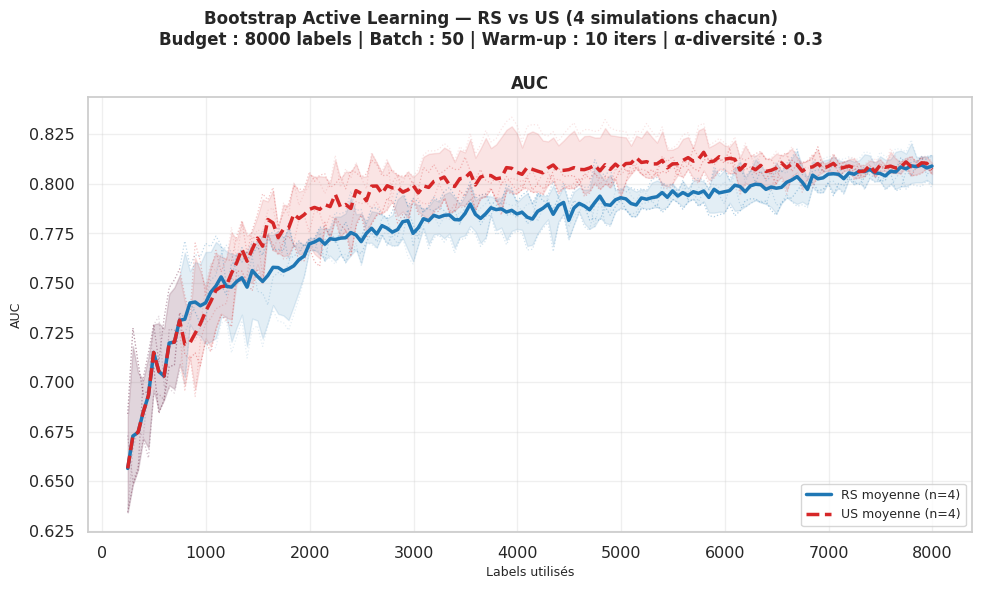

In [26]:
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)

COL_RS   = '#1f77b4'   # bleu
COL_US   = '#d62728'   # rouge
COL_LLM  = '#2ca02c'   # vert

alphas_rs  = np.linspace(0.12, 0.35, N_SIM)
alphas_llm = np.linspace(0.12, 0.35, N_LLM_SIMS)

fig, ax = plt.subplots(figsize=(11, 6))

# ── Trajectoires individuelles RS ─────────────────────────────────────────────
for j, sim in enumerate(results_RS_all):
    df_sim = pd.DataFrame(sim['results'])
    ax.plot(df_sim['labels_used'], df_sim['auc_rs'],
            color=COL_RS, alpha=alphas_rs[j], linewidth=0.9, linestyle=':')

# ── Trajectoires individuelles US ─────────────────────────────────────────────
for j, sim in enumerate(results_US_all):
    df_sim = pd.DataFrame(sim['results'])
    ax.plot(df_sim['labels_used'], df_sim['auc_us'],
            color=COL_US, alpha=alphas_rs[j], linewidth=0.9, linestyle=':')

# ── Trajectoires individuelles LLM ───────────────────────────────────────────
for j, df_sim in enumerate(df_llm_list):
    ax.plot(df_sim['labels_used'], df_sim['auc'],
            color=COL_LLM, alpha=alphas_llm[j], linewidth=0.9, linestyle=':')

# ── IC 90% ────────────────────────────────────────────────────────────────────
ax.fill_between(agg_rs['labels_used'],  agg_rs['auc_q05'],     agg_rs['auc_q95'],
                color=COL_RS,  alpha=0.12, zorder=1)
ax.fill_between(agg_us['labels_used'],  agg_us['auc_q05'],     agg_us['auc_q95'],
                color=COL_US,  alpha=0.12, zorder=1)
ax.fill_between(df_llm_agg['labels_used'], df_llm_agg['auc_q05'], df_llm_agg['auc_q95'],
                color=COL_LLM, alpha=0.12, zorder=1)

# ── Moyennes ──────────────────────────────────────────────────────────────────
ax.plot(agg_rs['labels_used'],     agg_rs['auc_mean'],
        color=COL_RS,  linewidth=2.5, label=f'RS moyenne (n={N_SIM})',      zorder=5)
ax.plot(agg_us['labels_used'],     agg_us['auc_mean'],
        color=COL_US,  linewidth=2.5, linestyle='--',
        label=f'US moyenne (n={N_SIM})',      zorder=5)
ax.plot(df_llm_agg['labels_used'], df_llm_agg['auc_mean'],
        color=COL_LLM, linewidth=2.5, linestyle='-.',
        label=f'LLM moyenne (n={N_LLM_SIMS})', zorder=5)

ax.set_title('AUC', fontsize=12, fontweight='bold')
ax.set_xlabel('Labels utilisés', fontsize=9)
ax.set_ylabel('AUC', fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')

fig.suptitle(
    f'Bootstrap Active Learning — RS vs US vs LLM ({MISTRAL_MODEL}, T={TEMPERATURE})\n'
    f'RS/US : {N_SIM} sims | LLM : {N_LLM_SIMS} sims | '
    f'Budget : {LABEL_MAX} labels | Batch : {BATCH_SIZE}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

fname = (
    f'{OUTPUT_DIR}bootstrap_RS_US_LLM_{METHODE}_{MISTRAL_MODEL}'
    f'_{N_LLM_SIMS}llmsims_{N_SIM}rssims_{LABEL_MAX}labels_AUC.png'
)
plt.savefig(fname, dpi=150, bbox_inches='tight')
print(f'✓ Graphique sauvegardé : {fname}')
plt.show()


## 9. Sauvegarde des résultats

In [27]:
df_rs.to_csv(f'{OUTPUT_DIR}results_RS_bootstrap.csv', index=False)
df_us.to_csv(f'{OUTPUT_DIR}results_US_bootstrap.csv', index=False)
agg_rs.to_csv(f'{OUTPUT_DIR}results_RS_aggregated.csv', index=False)
agg_us.to_csv(f'{OUTPUT_DIR}results_US_aggregated.csv', index=False)
df_llm_all.to_csv(f'{OUTPUT_DIR}results_LLM_bootstrap.csv', index=False)
df_llm_agg.to_csv(f'{OUTPUT_DIR}results_LLM_aggregated.csv', index=False)

print('✓ Fichiers sauvegardés')
print('  → results_RS_bootstrap.csv')
print('  → results_US_bootstrap.csv')
print('  → results_RS_aggregated.csv')
print('  → results_US_aggregated.csv')
print(f'  → results_LLM_bootstrap.csv  (format long, {len(df_llm_all)} lignes)')
print(f'  → results_LLM_aggregated.csv (moyenne/IC par labels_used)')


✓ Fichiers sauvegardés
  → results_RS_bootstrap.csv   (format long, toutes les simulations RS)
  → results_US_bootstrap.csv   (format long, toutes les simulations US)
  → results_RS_aggregated.csv  (moyenne/IC par labels_used)
  → results_US_aggregated.csv  (moyenne/IC par labels_used)
